[*] STARTING ARMORED LOCO VALIDATION (6 COHORTS)
 -> Held Out: GSE185263  | AUC: 0.665 (95% CI: [0.572, 0.749])
 -> Held Out: GSE236713  | AUC: 0.684 (95% CI: [0.609, 0.757])
 -> Held Out: GSE26440   | AUC: 0.646 (95% CI: [0.496, 0.778])
 -> Held Out: GSE272769  | AUC: 0.747 (95% CI: [0.667, 0.828])
 -> Held Out: GSE54514   | AUC: 0.765 (95% CI: [0.667, 0.863])
 -> Held Out: GSE95233   | AUC: 0.724 (95% CI: [0.612, 0.823])

[*] COMPUTING META-ANALYSIS STATISTICS
    -> Pooled LOCO AUC:  0.709 (95% CI: [0.671, 0.747])
    -> Cochran's Q:      4.25 (df=5)
    -> I^2 (Dispersion): 0.0%

[*] Generating Native Forest Plot...
[*] Export Complete! Forest Plot saved to Fig11_LOCO_Forest_Plot.pdf


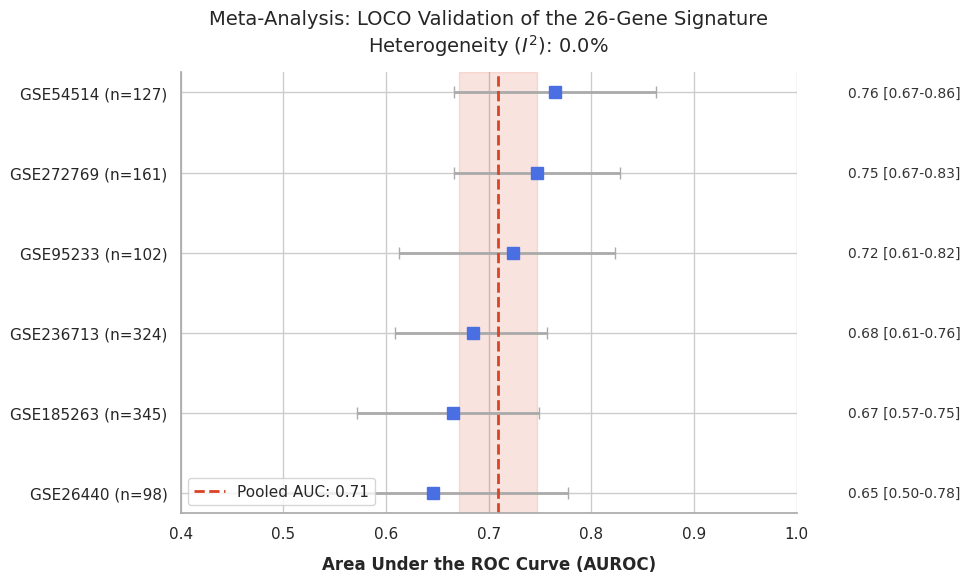

In [2]:
"""
06_loco_meta_analysis.py

The Armored Leave-One-Cohort-Out (LOCO) Validation Loop.
Excludes the blind Vault (GSE65682). Trains on 5 cohorts, tests on the 6th.
Calculates 1,000-iteration bootstrapped 95% CIs and computes Meta-Analysis 
Heterogeneity (I^2). Outputs both CSVs and a native Forest Plot.
"""

import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # <-- [THE FIX] Add this line!
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION
# ==========================================
BASE_DIR = Path.cwd().parent if "notebooks" in str(Path.cwd()) else Path(__file__).resolve().parents[2]
DATA_DIR = BASE_DIR / "data" / "processed" / "ml_tensors"
DEG_DIR = BASE_DIR / "data" / "processed" / "deg_tensors"
PLOT_DATA_DIR = BASE_DIR / "outputs" / "plot_data"
FIG_OUT = BASE_DIR / "outputs" / "figures"

HOLDOUT_COHORT = 'GSE65682'

# ==========================================
# XGBOOST TAG FIX
# ==========================================
class SklearnCompatibleXGBClassifier(xgb.XGBClassifier):
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        if hasattr(tags, "estimator_type"):
            tags.estimator_type = "classifier"
        elif isinstance(tags, dict):
            tags["estimator_type"] = "classifier"
        return tags

def main():
    print("==================================================")
    print("[*] STARTING ARMORED LOCO VALIDATION (6 COHORTS)")
    print("==================================================")
    
    PLOT_DATA_DIR.mkdir(parents=True, exist_ok=True)
    FIG_OUT.mkdir(parents=True, exist_ok=True)

    # 1. Load Data
    features_path = PLOT_DATA_DIR / "03_optimal_feature_list.csv"
    optimal_genes = pd.read_csv(features_path)['Optimal_Genes'].tolist()

    X_elite = pd.read_csv(DEG_DIR / "X_deg_master.csv.gz", compression='gzip')
    y = pd.read_csv(DATA_DIR / "y_master.csv")
    meta = pd.read_csv(DATA_DIR / "meta_master.csv")
    
    target_col = 'Mortality' if 'Mortality' in y.columns else y.columns[0]
    
    # 2. Isolate the Mega-Train Data (Exclude the Vault completely)
    train_mask = meta['Dataset'] != HOLDOUT_COHORT
    X_train_master = X_elite.loc[train_mask, optimal_genes]
    y_train_master = y.loc[train_mask, target_col].astype(int)
    meta_train_master = meta.loc[train_mask]

    # Get the 6 unique cohorts
    training_cohorts = meta_train_master['Dataset'].unique()
    
    forest_records = []
    roc_records = []

    # 3. Execute LOCO Loop
    for held_out_cohort in training_cohorts:
        # Split Train (5) and Test (1)
        test_mask = meta_train_master['Dataset'] == held_out_cohort
        train_mask = ~test_mask
        
        X_train = X_train_master[train_mask]
        y_train = y_train_master[train_mask]
        X_test = X_train_master[test_mask]
        y_test = y_train_master[test_mask]
        
        if len(y_test.unique()) < 2:
            print(f" -> [SKIP] {held_out_cohort} lacks mortality variation.")
            continue
            
        scale_weight = float((len(y_train) - y_train.sum()) / (y_train.sum() + 1e-9))
        
        loco_model = SklearnCompatibleXGBClassifier(
            n_estimators=100, 
            learning_rate=0.05, 
            max_depth=4,
            scale_pos_weight=scale_weight, 
            eval_metric='logloss', 
            objective='binary:logistic',
            random_state=42, 
            n_jobs=-1
        )
        
        loco_model.fit(X_train, y_train)
        probs = loco_model.predict_proba(X_test)[:, 1]
        
        base_auc = roc_auc_score(y_test, probs)
        
        # 4. Statistical Armor: 1,000 Bootstraps
        n_bootstraps = 1000
        rng = np.random.RandomState(42)
        boot_aucs = []
        y_test_arr = y_test.values
        
        for _ in range(n_bootstraps):
            indices = rng.randint(0, len(y_test_arr), len(y_test_arr))
            if len(np.unique(y_test_arr[indices])) < 2:
                continue
            boot_aucs.append(roc_auc_score(y_test_arr[indices], probs[indices]))
            
        auc_lower = np.percentile(boot_aucs, 2.5)
        auc_upper = np.percentile(boot_aucs, 97.5)
        auc_se = np.std(boot_aucs)  
        
        print(f" -> Held Out: {held_out_cohort:<10} | AUC: {base_auc:.3f} (95% CI: [{auc_lower:.3f}, {auc_upper:.3f}])")
        
        forest_records.append({
            "Cohort": held_out_cohort,
            "N_Patients": len(test_df) if 'test_df' in locals() else len(X_test),
            "AUC": base_auc,
            "AUC_Lower": auc_lower,
            "AUC_Upper": auc_upper,
            "SE": auc_se
        })
        
        fpr, tpr, _ = roc_curve(y_test, probs)
        for f, t in zip(fpr, tpr):
            roc_records.append({"Cohort": held_out_cohort, "FPR": f, "TPR": t})

    # ==========================================
    # Meta-Analysis Statistics
    # ==========================================
    print("\n" + "="*50)
    print("[*] COMPUTING META-ANALYSIS STATISTICS")
    print("="*50)

    df_forest = pd.DataFrame(forest_records)

    # Inverse Variance Weights
    df_forest['Weight'] = 1 / (df_forest['SE'] ** 2)
    sum_weights = df_forest['Weight'].sum()

    # Weighted Mean AUC
    weighted_mean_auc = (df_forest['AUC'] * df_forest['Weight']).sum() / sum_weights

    # Cochran's Q and I^2
    df_forest['Q_contrib'] = df_forest['Weight'] * ((df_forest['AUC'] - weighted_mean_auc) ** 2)
    Q = df_forest['Q_contrib'].sum()
    k = len(df_forest)
    df_stat = k - 1
    I2 = max(0.0, 100 * (Q - df_stat) / Q)

    se_pooled = 1 / np.sqrt(sum_weights)
    pooled_lower = weighted_mean_auc - (1.96 * se_pooled)
    pooled_upper = weighted_mean_auc + (1.96 * se_pooled)

    print(f"    -> Pooled LOCO AUC:  {weighted_mean_auc:.3f} (95% CI: [{pooled_lower:.3f}, {pooled_upper:.3f}])")
    print(f"    -> Cochran's Q:      {Q:.2f} (df={df_stat})")
    print(f"    -> I^2 (Dispersion): {I2:.1f}%")
    
    if I2 > 50:
        print("    -> [!] Moderate/High Heterogeneity Detected.")

    # ==========================================
    # Generation of the Python Forest Plot
    # ==========================================
    print("\n[*] Generating Native Forest Plot...")
    
    # Sort for aesthetic plotting
    df_forest = df_forest.sort_values(by='AUC', ascending=True).reset_index(drop=True)
    
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "#aaaaaa"})
    
    y_pos = np.arange(len(df_forest))
    
    # Plot individual cohorts
    plt.errorbar(df_forest['AUC'], y_pos, 
                 xerr=[df_forest['AUC'] - df_forest['AUC_Lower'], df_forest['AUC_Upper'] - df_forest['AUC']],
                 fmt='s', color='#4a6fe3', ecolor='#aaaaaa', elinewidth=2, capsize=4, markersize=8)
    
    # Add cohort labels and N sizes
    plt.yticks(y_pos, [f"{row['Cohort']} (n={int(row['N_Patients'])})" for _, row in df_forest.iterrows()], fontsize=11)
    
    # Add exact text labels for AUROC and CI on the right side
    for i, row in df_forest.iterrows():
        text_label = f"{row['AUC']:.2f} [{row['AUC_Lower']:.2f}-{row['AUC_Upper']:.2f}]"
        plt.text(1.05, i, text_label, va='center', fontsize=10, color='#333333')

    # Add the Pooled Estimate Line
    plt.axvline(x=weighted_mean_auc, color='#db4325', linestyle='--', linewidth=2, label=f'Pooled AUC: {weighted_mean_auc:.2f}')
    plt.axvspan(pooled_lower, pooled_upper, color='#db4325', alpha=0.15)

    plt.xlim(0.4, 1.0)
    plt.xlabel('Area Under the ROC Curve (AUROC)', fontsize=12, labelpad=10, fontweight='bold')
    plt.title(f"Meta-Analysis: LOCO Validation of the 26-Gene Signature\nHeterogeneity ($I^2$): {I2:.1f}%", fontsize=14, pad=15)
    plt.legend(loc='lower left', frameon=True)
    
    # Clean spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Save Outputs
    plot_pdf = FIG_OUT / "Fig11_LOCO_Forest_Plot.pdf"
    forest_csv = PLOT_DATA_DIR / "loco_forest_data.csv"
    roc_csv = PLOT_DATA_DIR / "loco_roc_curves.csv"

    plt.savefig(plot_pdf, dpi=300, bbox_inches='tight')
    df_forest.to_csv(forest_csv, index=False)
    pd.DataFrame(roc_records).to_csv(roc_csv, index=False)

    print(f"[*] Export Complete! Forest Plot saved to {plot_pdf.name}")

if __name__ == "__main__":
    main()